In [1]:
import os
import sys
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms

sys.path.append(os.path.abspath(".."))
from src.continual_learning import update_GPM_bases, apply_GPM_projection

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. GPU-Accelerated Data Loading ---
def get_gpu_mnist():
    """Loads full MNIST to GPU memory once."""
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
    train_set = datasets.MNIST('../data', train=True, download=True, transform=transform)
    test_set = datasets.MNIST('../data', train=False, download=True, transform=transform)

    # Push everything to DEVICE immediately
    train_data = train_set.data.unsqueeze(1).float().to(DEVICE) / 255.0
    train_data = (train_data - 0.1307) / 0.3081
    train_labels = train_set.targets.to(DEVICE)

    test_data = test_set.data.unsqueeze(1).float().to(DEVICE) / 255.0
    test_data = (test_data - 0.1307) / 0.3081
    test_labels = test_set.targets.to(DEVICE)

    return (train_data, train_labels), (test_data, test_labels)

(train_x, train_y), (test_x, test_y) = get_gpu_mnist()

def get_gpu_fashion_mnist():
    """Loads full Fashion-MNIST to GPU memory once."""
    # Official Fashion-MNIST mean and std for normalization
    mean, std = 0.2860, 0.3530

    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((mean,), (std,))])
    train_set = datasets.FashionMNIST('../data', train=True, download=True, transform=transform)
    test_set = datasets.FashionMNIST('../data', train=False, download=True, transform=transform)

    # Push to GPU and normalize manually to match your MNIST pipeline
    train_data = train_set.data.unsqueeze(1).float().to(DEVICE) / 255.0
    train_data = (train_data - mean) / std
    train_labels = train_set.targets.to(DEVICE)

    test_data = test_set.data.unsqueeze(1).float().to(DEVICE) / 255.0
    test_data = (test_data - mean) / std
    test_labels = test_set.targets.to(DEVICE)

    return (train_data, train_labels), (test_data, test_labels)

# To switch tasks, simply toggle the comment on these lines:
# (train_x, train_y), (test_x, test_y) = get_gpu_fashion_mnist()

def get_task_data(x, y, digits):
    mask = torch.stack([y == d for d in digits]).sum(0).bool()
    return x[mask], y[mask]

# --- 2. Model & Ebbinghaus Logic ---
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 400, bias=False),  # No bias for cleaner GPM SVD
            nn.ReLU(),
            nn.Linear(400, 400, bias=False),
            nn.ReLU(),
            nn.Linear(400, 10, bias=False)
        )
    def forward(self, x): return self.fc(x)

    def get_pre_activations(self, x):
        """Intercepts post-linear, pre-activation tensors for GPM SVD."""
        pre_acts = {}

        # Layer 1
        x = nn.Flatten()(x)
        x = self.fc[1](x)
        pre_acts['fc1'] = x.clone()

        # Layer 2
        x = self.fc[2](x) # ReLU
        x = self.fc[3](x)
        pre_acts['fc2'] = x.clone()

        # Layer 3
        x = self.fc[4](x) # ReLU
        x = self.fc[5](x)
        pre_acts['fc3'] = x.clone()

        return pre_acts

# --- 3. Eval Function for BWT/FWT ---
def evaluate(model, tasks_data):
    model.eval()
    accs = []
    with torch.no_grad():
        for tx, ty in tasks_data:
            out = model(tx)
            acc = (out.argmax(1) == ty).float().mean().item()
            accs.append(acc)
    model.train()
    return accs

def check_gradient_direction(linear_layers, feature_list):
    """
    Measures gradient geometry across past task subspaces.
    Extracts directional alignment (parallel) and vector magnitudes (parallel vs orthogonal)
    normalized to total gradient energy for 2D Cartesian phase portraits.
    """
    if feature_list is None:
        return None

    layer_stats = {}
    with torch.no_grad():
        for i, layer in enumerate(linear_layers):
            if i >= len(feature_list) or feature_list[i] is None or layer.weight.grad is None:
                continue

            grad = layer.weight.grad          # Shape: (Out, In)
            basis = feature_list[i]         # Shape: (In, K)

            # --- 1. COMPUTE TOTAL GRADIENT METRICS ---
            total_norm = torch.linalg.norm(grad).item()
            if total_norm == 0:
                layer_stats[f'layer_{i}'] = {
                    'net_alignment': 0.0, 'pos_energy': 0.0, 'neg_energy': 0.0,
                    'total_norm': 0.0, 'parallel_norm': 0.0, 'orthogonal_norm': 0.0,
                    'x_parallel_normalized': 0.0, 'y_orthogonal_normalized': 0.0
                }
                continue

            # --- RE-ENGINEERED TRUE SUBSPACE ALIGNMENT ---
            # Isolate the parallel gradient vector component
            parallel_grad = torch.mm(torch.mm(grad, basis), basis.t())
            orthogonal_grad = grad - parallel_grad
            parallel_norm = torch.linalg.norm(parallel_grad).item()
            orthogonal_norm = torch.linalg.norm(orthogonal_grad).item()

            if parallel_norm > 0:
                # 1. Project the current weights into the exact same past task subspace
                parallel_weight = torch.mm(torch.mm(layer.weight, basis), basis.t())

                # 2. Compute the true Frobenius inner product (Matrix Dot Product)
                # This measures if the update vector points WITH or AGAINST the existing weight vector
                # Formula: trace(A.T @ B)
                dot_product = torch.sum(parallel_grad * parallel_weight).item()

                # 3. Normalize the score by the magnitudes to get a true Cosine Similarity (-1 to +1)
                weight_norm = torch.linalg.norm(parallel_weight).item()
                if weight_norm > 0:
                    true_alignment = dot_product / (parallel_norm * weight_norm)
                else:
                    true_alignment = 0.0
            else:
                true_alignment = 0.0

            # --- MAP TO CLEAN VISUAL COORDINATES ---
            # X: The true cosine direction of the update multiplied by its energy share
            x_coord = true_alignment * (parallel_norm / total_norm)

            # Y: The pure orthogonal exploration volume share
            y_coord = orthogonal_norm / total_norm

            layer_stats[f'layer_{i}'] = {
                # Directional Signs (Legacy tracking for time overlay)
                'net_alignment': true_alignment,

                # Raw Vector Metrics (Energy Magnitudes)
                'total_norm': total_norm,
                'parallel_norm': parallel_norm,
                'orthogonal_norm': orthogonal_norm,

                # Phase Portrait Coordinates (Unit Bound)
                'x_parallel_normalized': x_coord,      # Range: -1.0 to +1.0
                'y_orthogonal_normalized': y_coord      # Range:  0.0 to +1.0
            }

    return layer_stats

# --- New Configuration ---
EVAL_EVERY_N_BATCHES = 50

class MetricsTracker:
    def __init__(self):
        self.history = {
            'steps': [],
            'accuracies': [], # List of lists [acc_t0, acc_t1, ...]
            'losses': [],
            'stability_means': [],
            'stability_max': []
        }

    def log(self, step, accs, loss, stability_list):
        self.history['steps'].append(step)
        self.history['accuracies'].append(accs)
        self.history['losses'].append(loss)

        # Track stability stats to see the "Inertia" growth
        all_s = torch.cat([s.view(-1) for s in stability_list])
        self.history['stability_means'].append(all_s.mean().item())
        self.history['stability_max'].append(all_s.max().item())

class AlignmentTracker:
    def __init__(self, num_tasks=5):
        self.steps = []
        self.task_boundaries = []

        # Core metric histories organized by layer keys (e.g., 'layer_0', 'layer_1')
        self.net_alignments = {}
        self.total_norm = {}
        self.parallel_norm = {}
        self.orthogonal_norm = {}
        self.x_parallel_normalized = {}
        self.y_orthogonal_normalized = {}

        # Track accuracy histories as separate step-aligned lists
        self.num_tasks = num_tasks
        self.accuracies = {f'task_{i}': [] for i in range(num_tasks)}
        self.acc_steps = []  # Timeline tracking for evaluation steps

    def log_gradients(self, step, stats):
        """
        Accepts the full stats dictionary across all calculated layers
        and appends metrics into layer-specific tracking arrays dynamically.
        """
        if not stats:
            return

        self.steps.append(step)

        for layer_key, layer_metrics in stats.items():
            # Dynamically initialize sub-lists for newly encountered layer names
            if layer_key not in self.net_alignments:
                self.net_alignments[layer_key] = []
                self.total_norm[layer_key] = []
                self.parallel_norm[layer_key] = []
                self.orthogonal_norm[layer_key] = []
                self.x_parallel_normalized[layer_key] = []
                self.y_orthogonal_normalized[layer_key] = []

            # Append metrics to the active layer profile
            self.net_alignments[layer_key].append(layer_metrics['net_alignment'])
            self.total_norm[layer_key].append(layer_metrics['total_norm'])
            self.parallel_norm[layer_key].append(layer_metrics['parallel_norm'])
            self.orthogonal_norm[layer_key].append(layer_metrics['orthogonal_norm'])
            self.x_parallel_normalized[layer_key].append(layer_metrics['x_parallel_normalized'])
            self.y_orthogonal_normalized[layer_key].append(layer_metrics['y_orthogonal_normalized'])

    def log_accuracies(self, step, acc_list):
        self.acc_steps.append(step)
        for i, acc in enumerate(acc_list):
            if i < self.num_tasks:
                self.accuracies[f'task_{i}'].append(acc)

In [2]:
# --- 2. MVP Hyperparameters ---
TASKS = [[0, 1], [2, 3], [4, 5], [6, 7], [8, 9]]
LR = 1e-2
BATCH_SIZE = 64
EPOCHS_PER_TASK = 10
GPM_THRESHOLD = 0.97  # Standard GPM variance retention threshold
ALPHA = 1e-2         # Your leak factor jiggle! Set to 0.0 for pure GPM control baseline


# --- 3. Initialization ---
model = SimpleMLP().to(DEVICE)
optimizer = optim.SGD(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()
align_tracker = AlignmentTracker(num_tasks=len(TASKS))

# Cache references to your linear modules for fast gradient manipulation
linear_layers = [model.fc[1], model.fc[3], model.fc[5]]

# Pull down the pre-loaded data arrays from your setup
(train_x, train_y), (test_x, test_y) = get_gpu_mnist()
all_test_tasks = [get_task_data(test_x, test_y, t) for t in TASKS]

feature_list = None  # Holds our evolving projection bases
total_steps = 0

print(f"Running Leaky GPM MVP on {DEVICE} | Alpha: {ALPHA} | Threshold: {GPM_THRESHOLD}")
print("-" * 70)

EVAL_EVERY_N_BATCHES = 50  # Balanced interval for clear charting

for t_idx, digits in enumerate(TASKS):
    tx, ty = get_task_data(train_x, train_y, digits)

    for epoch in range(EPOCHS_PER_TASK):
        model.train()
        indices = torch.randperm(len(tx))

        for i in range(0, len(tx), BATCH_SIZE):
            batch_idx = indices[i:i+BATCH_SIZE]
            bx, by = tx[batch_idx], ty[batch_idx]

            optimizer.zero_grad()
            output = model(bx)
            loss = criterion(output, by)
            loss.backward()

            if feature_list is not None:
                stats = check_gradient_direction(linear_layers, feature_list)
                align_tracker.log_gradients(total_steps, stats)
                apply_GPM_projection(linear_layers, feature_list, alpha=ALPHA, use_gating=True)

            optimizer.step()

            # --- HIGH RESOLUTION ACCURACY TRACKING ---
            if total_steps % EVAL_EVERY_N_BATCHES == 0:
                # evaluate() shifts model to eval mode internally and handles torch.no_grad
                current_accs = evaluate(model, all_test_tasks)
                align_tracker.log_accuracies(total_steps, current_accs)

            total_steps += 1

    align_tracker.task_boundaries.append(total_steps)
    # Perform your standard SVD update_GPM_bases down here...
    # Task Boundary: Capture memory representations of current task to expand the subspace
    print(f"Updating GPM Subspace Basis with Task {t_idx} signatures...")

    # Gather a representative sample batch from the current task to build representations
    sample_size = min(300, len(tx))
    sample_images = tx[:sample_size]

    feature_list, current_ranks = update_GPM_bases(
        model, sample_images, threshold=GPM_THRESHOLD, feature_list=feature_list, activation_fn=torch.relu
    )
    print(f"Subspace Ranks after Task {t_idx} accumulation: {current_ranks}")

Running Leaky GPM MVP on cuda | Alpha: 0.01 | Threshold: 0.97
----------------------------------------------------------------------
Updating GPM Subspace Basis with Task 0 signatures...
Subspace Ranks after Task 0 accumulation: [np.int64(71), np.int64(18), np.int64(2)]
Updating GPM Subspace Basis with Task 1 signatures...
Subspace Ranks after Task 1 accumulation: [np.int64(100), np.int64(58), np.int64(8)]
Updating GPM Subspace Basis with Task 2 signatures...
Subspace Ranks after Task 2 accumulation: [np.int64(102), np.int64(70), np.int64(14)]
Updating GPM Subspace Basis with Task 3 signatures...
Subspace Ranks after Task 3 accumulation: [np.int64(92), np.int64(61), np.int64(13)]
Updating GPM Subspace Basis with Task 4 signatures...
Subspace Ranks after Task 4 accumulation: [np.int64(90), np.int64(60), np.int64(14)]


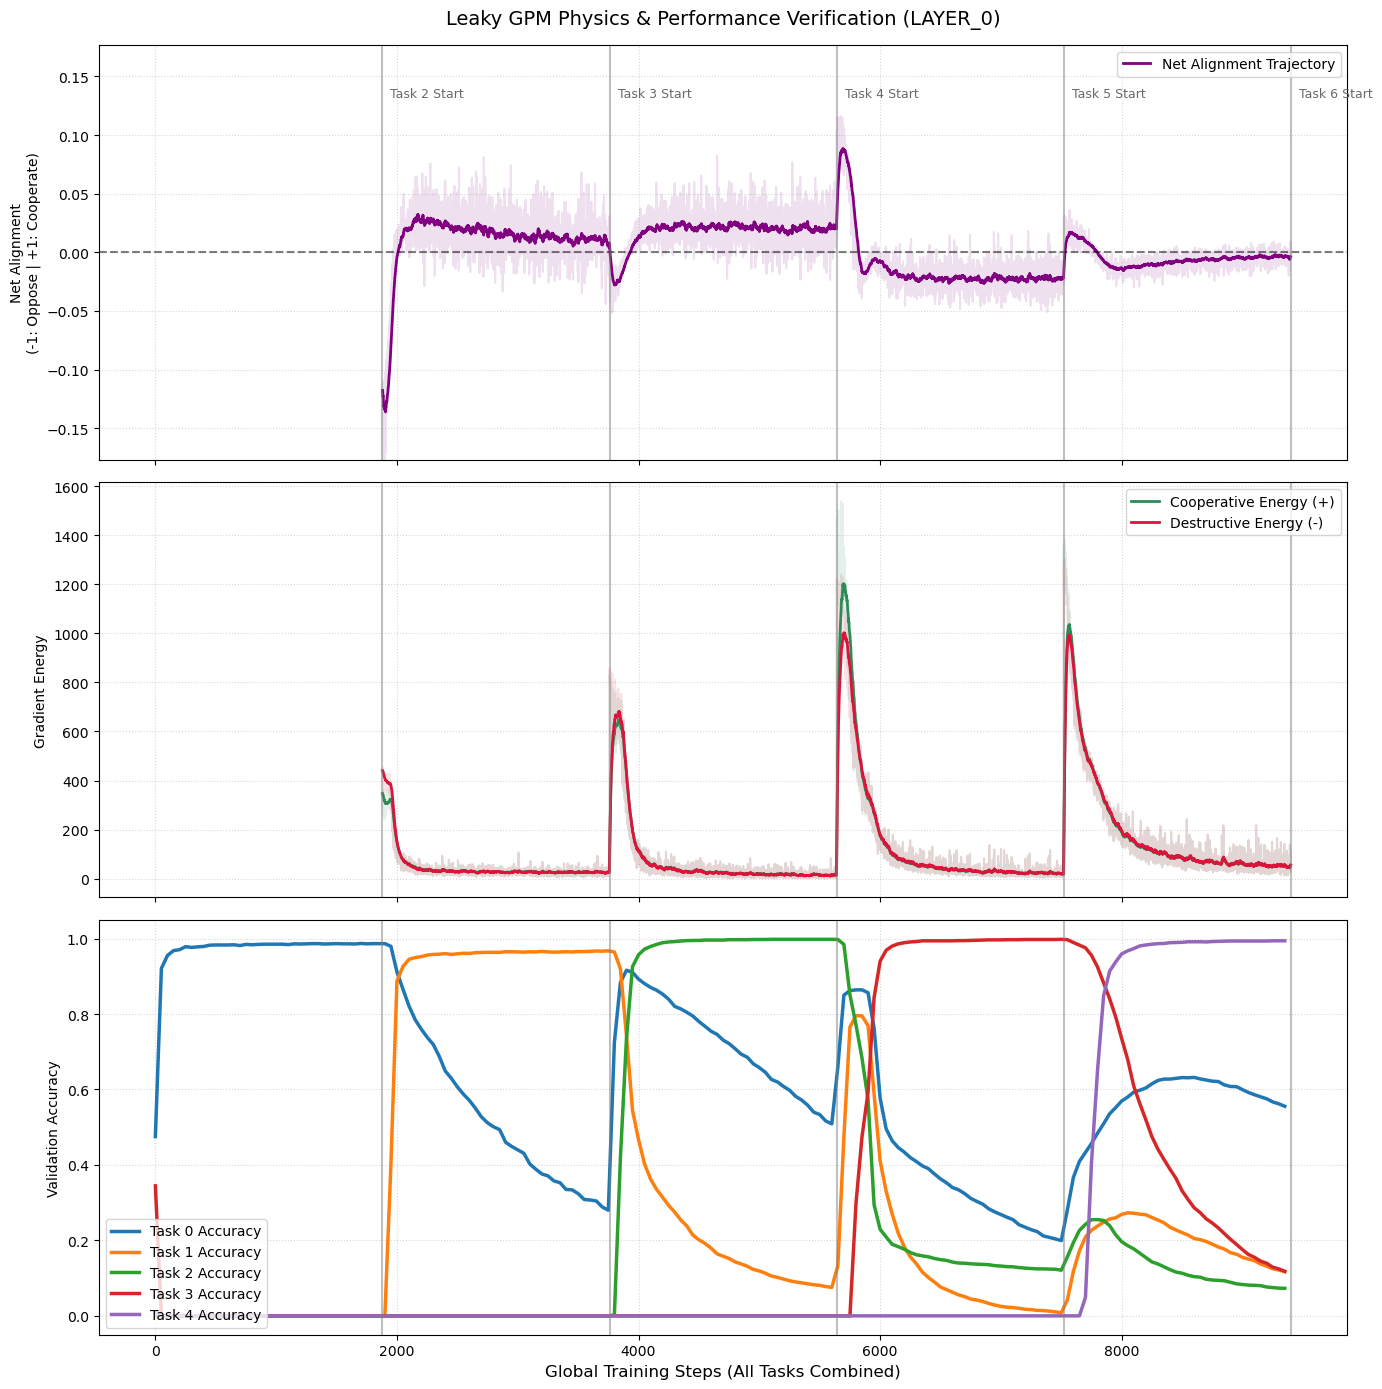

In [23]:
def plot_physics_with_accuracy(tracker, target_layer='layer_0', smoothing_alpha=0.05):
    """
    Plots a 3-panel vertical stack sharing a single global timeline.
    Panel 1: Net Directional Alignment Score
    Panel 2: Split Cooperative vs Destructive Energies
    Panel 3: Multi-task validation accuracy trajectories

    Supports multi-layer nested dictionary tracking metrics.
    """
    import pandas as pd
    import matplotlib.pyplot as plt

    # Ensure the requested layer has tracking logs populated
    if target_layer not in tracker.net_alignments:
        print(f"No tracking history found for layer key: {target_layer}")
        return

    # Expand layout to 3 vertical subplots with a shared X-axis
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 14), sharex=True)
    steps = tracker.steps

    # Extract layer-specific raw histories
    raw_net = tracker.net_alignments[target_layer]
    raw_pos = tracker.pos_energies[target_layer]
    raw_neg = tracker.neg_energies[target_layer]

    # Calculate EMA smoothing for the gradient components
    net_series = pd.Series(raw_net)
    pos_series = pd.Series(raw_pos)
    neg_series = pd.Series(raw_neg)

    smoothed_net = net_series.ewm(alpha=smoothing_alpha, adjust=False).mean().values
    smoothed_pos = pos_series.ewm(alpha=smoothing_alpha, adjust=False).mean().values
    smoothed_neg = neg_series.ewm(alpha=smoothing_alpha, adjust=False).mean().values

    # --- PANEL 1: Net Directional Alignment Score ---
    ax1.plot(steps, raw_net, color='purple', alpha=0.12)
    ax1.plot(steps, smoothed_net, color='purple', linewidth=2, label='Net Alignment Trajectory')
    ax1.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax1.set_ylabel('Net Alignment\n(-1: Oppose | +1: Cooperate)', fontsize=10)
    ax1.set_title(f'Leaky GPM Physics & Performance Verification ({target_layer.upper()})', fontsize=14, pad=15)
    ax1.grid(True, linestyle=':', alpha=0.5)
    ax1.legend(loc='upper right')

    # Automatically scale Panel 1 symmetrically
    align_bound = max(abs(min(smoothed_net)), abs(max(smoothed_net))) * 1.3
    ax1.set_ylim(-align_bound, align_bound)

    # --- PANEL 2: Raw Directional Energies ---
    ax2.plot(steps, raw_pos, color='seagreen', alpha=0.12)
    ax2.plot(steps, raw_neg, color='crimson', alpha=0.12)
    ax2.plot(steps, smoothed_pos, color='seagreen', linewidth=2, label='Cooperative Energy (+)')
    ax2.plot(steps, smoothed_neg, color='crimson', linewidth=2, label='Destructive Energy (-)')
    ax2.set_ylabel('Gradient Energy', fontsize=10)
    ax2.grid(True, linestyle=':', alpha=0.5)
    ax2.legend(loc='upper right')

    # --- PANEL 3: High-Resolution Task Accuracies ---
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    acc_steps = tracker.acc_steps

    for task_idx in range(tracker.num_tasks):
        task_accs = tracker.accuracies[f'task_{task_idx}']
        if any(a > 0 for a in task_accs):
            ax3.plot(acc_steps, task_accs, color=colors[task_idx], linewidth=2.5,
                     label=f'Task {task_idx} Accuracy')

    ax3.set_ylabel('Validation Accuracy', fontsize=10)
    ax3.set_ylim(-0.05, 1.05)
    ax3.set_xlabel('Global Training Steps (All Tasks Combined)', fontsize=12)
    ax3.grid(True, linestyle=':', alpha=0.5)
    ax3.legend(loc='lower left')

    # Overlay vertical epoch markers across all 3 structural panels
    for i, boundary_step in enumerate(tracker.task_boundaries):
        if i < len(tracker.task_boundaries):
            for ax in [ax1, ax2, ax3]:
                ax.axvline(boundary_step, color='gray', linestyle='-', alpha=0.5)
            # Anchor text markers using Panel 1's dynamic boundary ceilings
            ax1.text(boundary_step, align_bound * 0.75, f'  Task {i+2} Start', color='dimgray', fontsize=9)

    plt.tight_layout()
    plt.savefig(f'leaky_gpm_correlation_plot_{target_layer}.png', dpi=300)
    plt.show()

# Execution Call
plot_physics_with_accuracy(align_tracker, target_layer='layer_0')

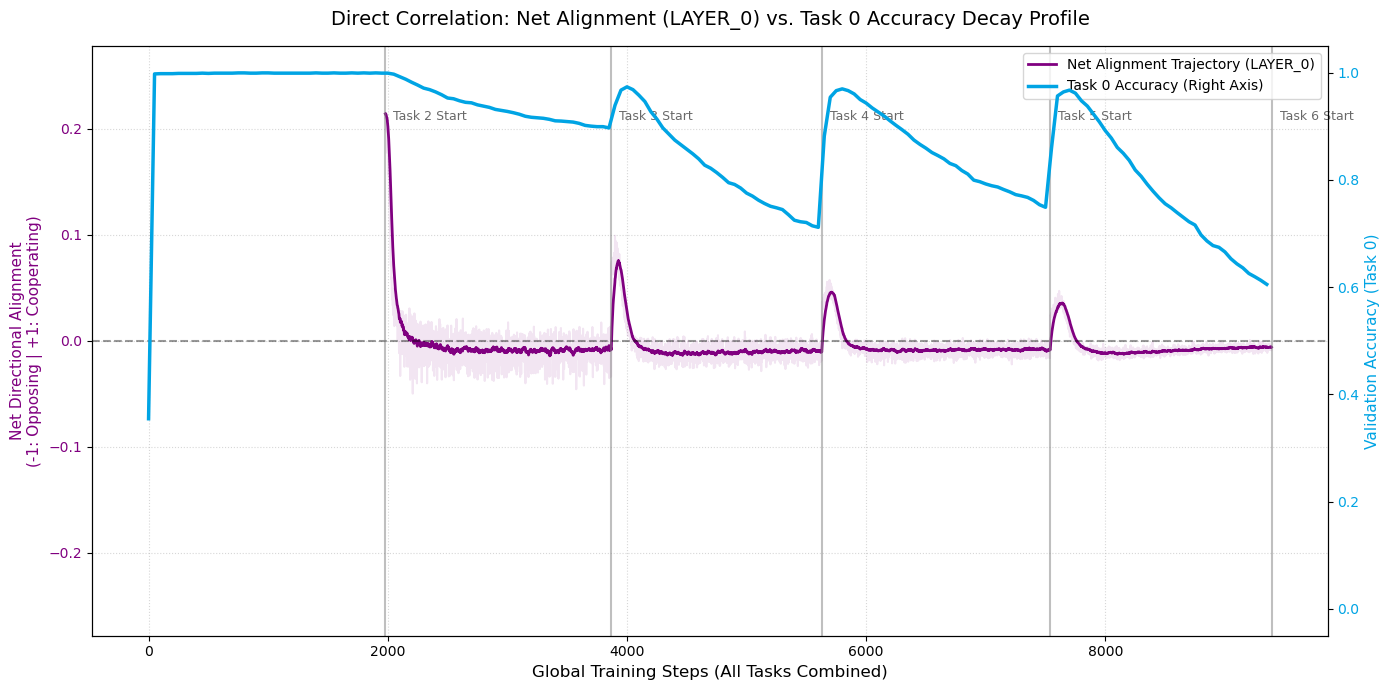

In [5]:
def plot_alignment_accuracy_overlay(tracker, target_task_idx=0, target_layer='layer_0', smoothing_alpha=0.05):
    """
    Overlays a specific task's accuracy curve directly on top of the Net Alignment score
    using a secondary y-axis for high-resolution correlation analysis.
    Supports multi-layer nested dictionary tracking metrics.

    Args:
        tracker: The AlignmentTracker instance holding run data.
        target_task_idx: The integer index of the historical task accuracy to overlay (e.g., 0 for Task 1).
        target_layer: The string key of the target layer (e.g., 'layer_0').
        smoothing_alpha: EMA smoothing coefficient for the gradient trend line.
    """
    import pandas as pd
    import matplotlib.pyplot as plt

    # Ensure the requested layer has tracking logs populated
    if target_layer not in tracker.net_alignments:
        print(f"No alignment history found for layer key: {target_layer}")
        return

    fig, ax1 = plt.subplots(figsize=(14, 7))
    steps = tracker.steps

    # Extract raw alignment array for the specific layer
    raw_alignments = tracker.net_alignments[target_layer]

    # --- LEFT AXIS: Net Alignment Score ---
    net_series = pd.Series(raw_alignments)
    smoothed_net = net_series.ewm(alpha=smoothing_alpha, adjust=False).mean().values

    # Plot faint raw alignment noise and heavy smoothed trajectory
    ax1.plot(steps, raw_alignments, color='purple', alpha=0.10)
    line_align, = ax1.plot(steps, smoothed_net, color='purple', linewidth=2,
                           label=f'Net Alignment Trajectory ({target_layer.upper()})')

    ax1.axhline(0, color='black', linestyle='--', alpha=0.4)
    ax1.set_xlabel('Global Training Steps (All Tasks Combined)', fontsize=12)
    ax1.set_ylabel('Net Directional Alignment\n(-1: Opposing | +1: Cooperating)', color='purple', fontsize=11)
    ax1.tick_params(axis='y', labelcolor='purple')
    ax1.grid(True, linestyle=':', alpha=0.5)

    # Automatically fit alignment limits with a clean symmetrical buffer
    align_bound = max(abs(min(smoothed_net)), abs(max(smoothed_net))) * 1.3
    ax1.set_ylim(-align_bound, align_bound)

    # --- RIGHT AXIS: Target Task Accuracy ---
    ax2 = ax1.twinx()  # Instantiate a companion axis that shares the same x-timeline

    acc_steps = tracker.acc_steps
    task_accs = tracker.accuracies[f'task_{target_task_idx}']

    # Plot the accuracy curve using a highly visible contrast color
    line_acc, = ax2.plot(acc_steps, task_accs, color='#00a4e4', linewidth=2.5,
                          label=f'Task {target_task_idx} Accuracy (Right Axis)')

    ax2.set_ylabel(f'Validation Accuracy (Task {target_task_idx})', color='#00a4e4', fontsize=11)
    ax2.tick_params(axis='y', labelcolor='#00a4e4')
    ax2.set_ylim(-0.05, 1.05)

    # Combined Legend handling for overlapping twin axes
    lines = [line_align, line_acc]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right')

    # Draw vertical task boundary lines across the shared coordinate grid
    for i, boundary_step in enumerate(tracker.task_boundaries):
        if i < len(tracker.task_boundaries):
            ax1.axvline(boundary_step, color='gray', linestyle='-', alpha=0.5)
            # Use data coordinates relative to the updated y-axis ceiling limits
            ax1.text(boundary_step, align_bound * 0.75, f'  Task {i+2} Start', color='dimgray', fontsize=9)

    plt.title(f'Direct Correlation: Net Alignment ({target_layer.upper()}) vs. Task {target_task_idx} Accuracy Decay Profile', fontsize=14, pad=15)
    plt.tight_layout()
    plt.savefig(f'leaky_gpm_overlay_{target_layer}_task_{target_task_idx}.png', dpi=300)
    plt.show()

# Execution Call
plot_alignment_accuracy_overlay(align_tracker, target_task_idx=0, target_layer='layer_0')

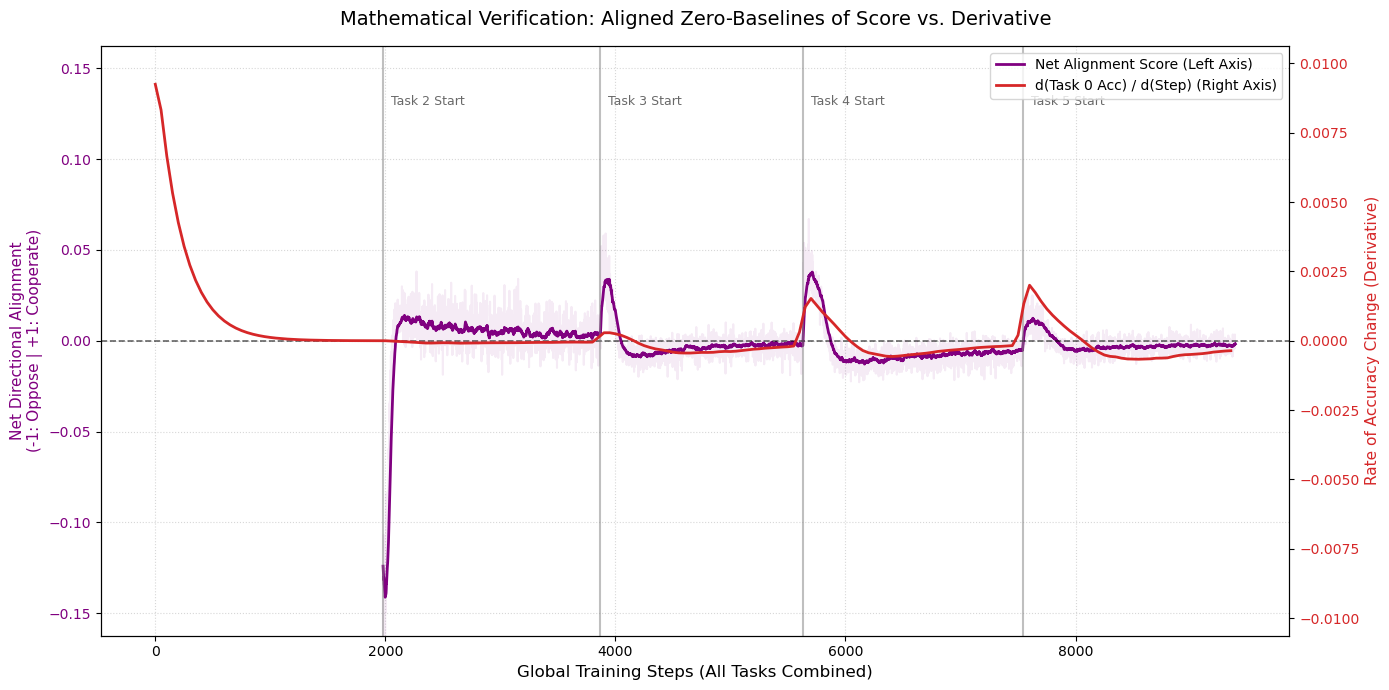

In [33]:
def plot_alignment_and_acc_derivative_aligned(tracker, target_task_idx=0, smoothing_alpha=0.05):
    """
    Computes the numerical derivative of the accuracy curve and overlays it
    directly with the Net Alignment trajectory, forcing their zero baselines to align.
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    fig, ax1 = plt.subplots(figsize=(14, 7))
    steps = tracker.steps

    # --- 1. LEFT AXIS: Net Alignment Score (EMA Smoothed) ---
    net_series = pd.Series(tracker.net_alignments)
    smoothed_net = net_series.ewm(alpha=smoothing_alpha, adjust=False).mean().values

    ax1.plot(steps, tracker.net_alignments, color='purple', alpha=0.08)
    line_align, = ax1.plot(steps, smoothed_net, color='purple', linewidth=2,
                           label='Net Alignment Score (Left Axis)')

    ax1.set_xlabel('Global Training Steps (All Tasks Combined)', fontsize=12)
    ax1.set_ylabel('Net Directional Alignment\n(-1: Oppose | +1: Cooperate)', color='purple', fontsize=11)
    ax1.tick_params(axis='y', labelcolor='purple')
    ax1.grid(True, linestyle=':', alpha=0.5)

    # --- 2. RIGHT AXIS: Numerical Derivative of Accuracy ---
    acc_steps = np.array(tracker.acc_steps)
    task_accs = np.array(tracker.accuracies[f'task_{target_task_idx}'])

    # Calculate the gradient: d(Acc)/d(Step)
    acc_derivative = np.gradient(task_accs, acc_steps)

    # Smooth the derivative to match the EMA alignment profile
    deriv_series = pd.Series(acc_derivative)
    smoothed_deriv = deriv_series.ewm(alpha=0.2, adjust=False).mean().values

    ax2 = ax1.twinx()
    line_deriv, = ax2.plot(acc_steps, smoothed_deriv, color='#d62728', linewidth=2, linestyle='-',
                            label=f'd(Task {target_task_idx} Acc) / d(Step) (Right Axis)')

    ax2.set_ylabel('Rate of Accuracy Change (Derivative)', color='#d62728', fontsize=11)
    ax2.tick_params(axis='y', labelcolor='#d62728')

    # --- 3. HARD LOCK THE ZERO BASELINES ---
    # Find the maximum absolute limits to create perfectly balanced symmetrical axes
    align_max = max(abs(smoothed_net.min()), abs(smoothed_net.max())) * 1.15
    deriv_max = max(abs(smoothed_deriv.min()), abs(smoothed_deriv.max())) * 1.15

    # Setting symmetrical limits (-X, +X) forces the zero line to sit precisely in the center for both axes
    ax1.set_ylim(-align_max, align_max)
    ax2.set_ylim(-deriv_max, deriv_max)

    # Draw one single explicit shared horizontal line across the unified center
    ax1.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.6, label='Shared Zero Baseline')

    # Combined Legend
    lines = [line_align, line_deriv]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right')

    # Task Boundaries
    for i, boundary_step in enumerate(tracker.task_boundaries):
        if i < len(tracker.task_boundaries) - 1:
            ax1.axvline(boundary_step, color='gray', linestyle='-', alpha=0.5)
            ax1.text(boundary_step, ax1.get_ylim()[1]*0.8, f'  Task {i+2} Start', color='dimgray', fontsize=9)

    plt.title(f'Mathematical Verification: Aligned Zero-Baselines of Score vs. Derivative', fontsize=14, pad=15)
    plt.tight_layout()
    plt.savefig(f'leaky_gpm_zero_aligned_derivative_task_{target_task_idx}.png', dpi=300)
    plt.show()

# Call this at the very end of your script execution
plot_alignment_and_acc_derivative_aligned(align_tracker)

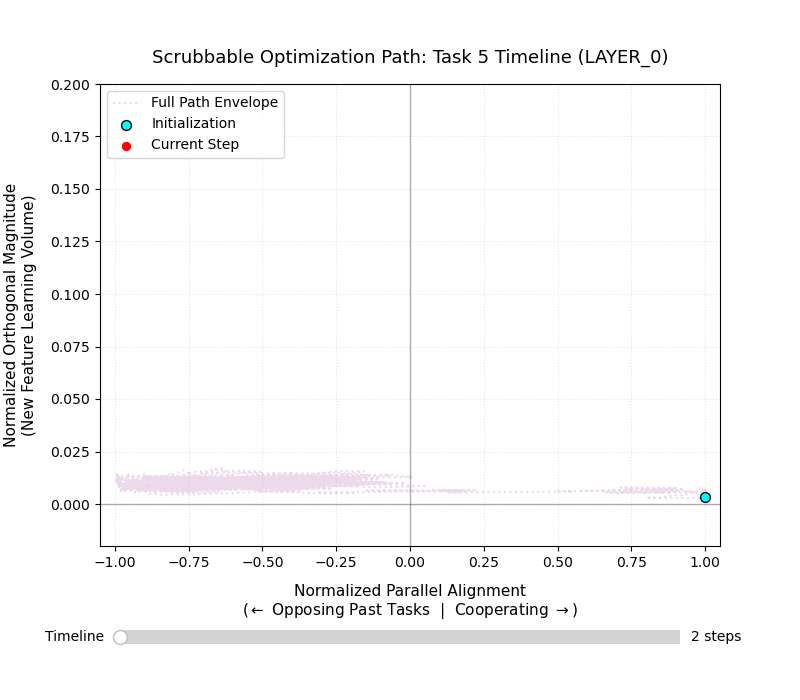

In [6]:
%matplotlib ipympl

def plot_single_task_phase_portrait_interactive(tracker, target_task_idx=2, target_layer='layer_0', smoothing_alpha=0.1):
    """
    Plots an interactive, scrollable 2D phase portrait for a single chosen task block.
    Uses a Matplotlib Slider widget to scrub through the optimization timeline manually.
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.collections import LineCollection
    from matplotlib.widgets import Slider

    # 1. Determine step boundaries for the targeted task block
    start_step_idx = 0 if target_task_idx == 0 else tracker.task_boundaries[target_task_idx - 1]
    end_step_idx = tracker.task_boundaries[target_task_idx]

    # 2. Slice tracker global steps
    global_steps = np.array(tracker.steps)
    task_mask = (global_steps >= start_step_idx) & (global_steps < end_step_idx)
    sliced_steps = global_steps[task_mask]
    num_task_steps = len(sliced_steps)

    # 3. Extract independent flat tracking vectors directly using the mask
    x_raw = np.array(tracker.x_parallel_normalized)[task_mask]
    y_raw = np.array(tracker.y_orthogonal_normalized)[task_mask]

    if len(x_raw) == 0:
        print(f"No tracker data found for {target_layer} in Task {target_task_idx + 1}.")
        return

    # 4. Apply EMA smoothing over the single isolated task vector
    x_smoothed = pd.Series(x_raw).ewm(alpha=smoothing_alpha, adjust=False).mean().values
    y_smoothed = pd.Series(y_raw).ewm(alpha=smoothing_alpha, adjust=False).mean().values

    # 5. Initialize the figure and make space at the bottom for the slider widget
    fig, ax = plt.subplots(figsize=(8, 7)) # Marginally smaller size fits VS Code output panes better
    plt.subplots_adjust(bottom=0.22)       # Lift the main plot higher to secure clear breathing room

    # --- GEOMETRIC FRAMING ---
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-0.02, max(0.2, max(y_smoothed) * 1.2))
    ax.axhline(0, color='black', linestyle='-', linewidth=1.0, alpha=0.3)
    ax.axvline(0, color='black', linestyle='-', linewidth=1.0, alpha=0.3)
    ax.grid(True, linestyle=':', alpha=0.3)

    # Axis Labels
    ax.set_xlabel('Normalized Parallel Alignment\n' + r'($\leftarrow$ Opposing Past Tasks  |  Cooperating $\rightarrow$)', fontsize=11, labelpad=10)
    ax.set_ylabel('Normalized Orthogonal Magnitude\n(New Feature Learning Volume)', fontsize=11, labelpad=10)
    ax.set_title(f'Scrubbable Optimization Path: Task {target_task_idx + 1} Timeline ({target_layer.upper()})', fontsize=13, pad=15)

    # --- STATIC TRACKS ---
    # Plot a faint baseline curve showing the total path envelope for context
    ax.plot(x_smoothed, y_smoothed, color='purple', alpha=0.15, linestyle=':', label='Full Path Envelope')

    # Static initialization point marker
    ax.scatter(x_smoothed[0], y_smoothed[0], color='cyan', edgecolor='black', s=50, zorder=5, label='Initialization')

    # --- ANIMATED COMPONENTS ---
    # Initialize an empty LineCollection that updates dynamically via the slider
    cmap = plt.get_cmap('plasma')
    norm = plt.Normalize(0, num_task_steps)
    animated_lc = LineCollection([], cmap=cmap, norm=norm, linewidth=2.5, alpha=0.9)
    ax.add_collection(animated_lc)

    # Initialize a tracking dot that sits on the current active step index
    current_head = ax.scatter([], [], color='red', edgecolor='white', s=60, zorder=6, label='Current Step')
    ax.legend(loc='upper left')

    # --- THE LIVE WIDGET SLIDER ---
    # Construct a slightly thicker, more responsive bounding box for the web canvas
    slider_ax = fig.add_axes([0.15, 0.07, 0.7, 0.04], facecolor='lightgray')
    time_slider = Slider(
        ax=slider_ax,
        label='Timeline ',
        valmin=2,
        valmax=num_task_steps,
        valinit=2,
        valfmt='%d steps',
        color='purple'
    )

    def update_plot(val):
        current_idx = int(time_slider.val)

        # Prevent edge index out-of-bounds clipping inside the slider callback
        if current_idx >= num_task_steps:
            current_idx = num_task_steps - 1

        x_slice = x_smoothed[:current_idx]
        y_slice = y_smoothed[:current_idx]

        points = np.array([x_slice, y_slice]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)

        animated_lc.set_segments(segments)
        animated_lc.set_array(np.arange(current_idx))

        current_head.set_offsets(np.c_[[x_smoothed[current_idx-1]], [y_smoothed[current_idx-1]]])

        # Use canvas.draw() for robust updates inside Jupyter outputs
        fig.canvas.draw()

    time_slider.on_changed(update_plot)
    fig.time_slider_reference = time_slider

    plt.show()

# Execute the interactive animator
plot_single_task_phase_portrait_interactive(align_tracker, target_task_idx=4, target_layer='layer_0')

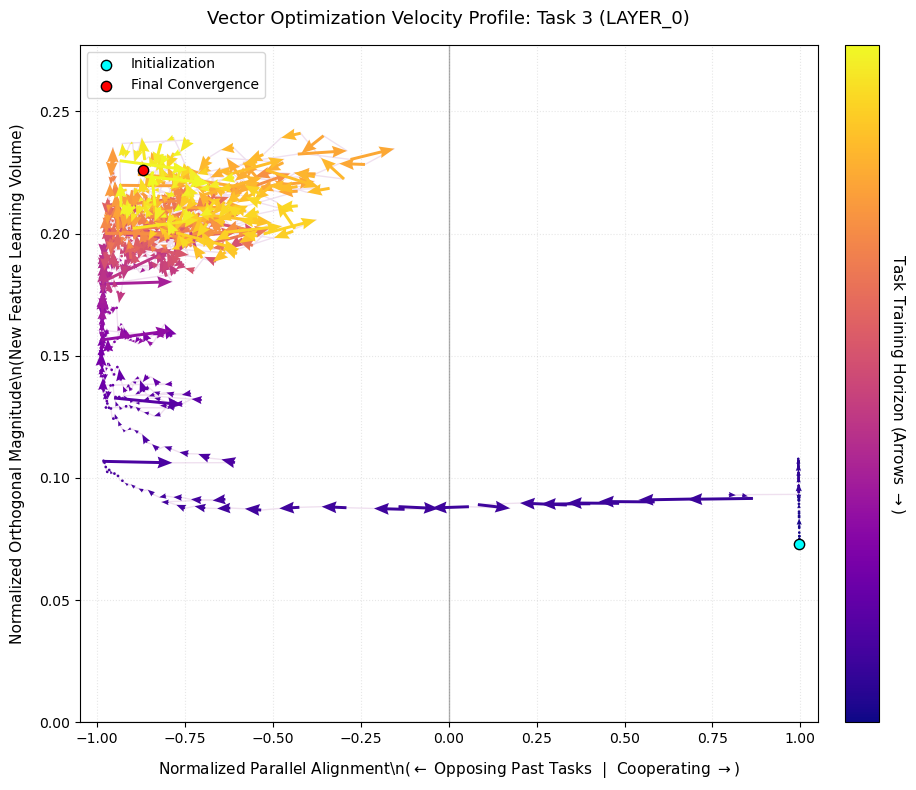

In [ ]:
%matplotlib inline

def plot_single_task_quiver(tracker, target_task_idx=2, target_layer='layer_0',
                            smoothing_alpha=0.1, arrow_stride=40):
    """
    Plots a static 2D phase portrait for a single task using quiver arrows,
    updated to fetch data from multi-layer dictionary metrics.
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    # 1. Map step boundaries for the targeted task block
    start_step_idx = 0 if target_task_idx == 0 else tracker.task_boundaries[target_task_idx - 1]
    end_step_idx = tracker.task_boundaries[target_task_idx]

    # 2. Isolate steps
    global_steps = np.array(tracker.steps)
    task_mask = (global_steps >= start_step_idx) & (global_steps < end_step_idx)
    sliced_steps = global_steps[task_mask]

    # 3. Safely extract vectors for the specified layer key
    if target_layer not in tracker.x_parallel_normalized:
        print(f"No tracking logs found for layer: {target_layer}")
        return

    x_raw = np.array(tracker.x_parallel_normalized[target_layer])[task_mask]
    y_raw = np.array(tracker.y_orthogonal_normalized[target_layer])[task_mask]

    if len(x_raw) == 0:
        print(f"No data points captured for {target_layer} during Task {target_task_idx + 1}.")
        return

    # 4. Smooth coordinates
    x_smoothed = pd.Series(x_raw).ewm(alpha=smoothing_alpha, adjust=False).mean().values
    y_smoothed = pd.Series(y_raw).ewm(alpha=smoothing_alpha, adjust=False).mean().values

    fig, ax = plt.subplots(figsize=(10, 8))

    # --- GEOMETRIC TRAILS ---
    ax.plot(x_smoothed, y_smoothed, color='purple', alpha=0.12, linewidth=1.0, zorder=1)

    dx = np.diff(x_smoothed)
    dy = np.diff(y_smoothed)
    quiver_indices = np.arange(0, len(dx), arrow_stride)

    x_pos = x_smoothed[quiver_indices]
    y_pos = y_smoothed[quiver_indices]
    u_dir = dx[quiver_indices]
    v_dir = dy[quiver_indices]

    colors = np.arange(len(quiver_indices))
    cmap = plt.get_cmap('plasma')

    quiver = ax.quiver(x_pos, y_pos, u_dir, v_dir, colors, cmap=cmap,
                       scale_units='xy', angles='xy', scale=1,
                       width=0.004, headwidth=4, headlength=5, zorder=3)

    cbar = fig.colorbar(quiver, ax=ax, pad=0.03)
    cbar.set_label(r'Task Training Horizon (Arrows $\rightarrow$)', fontsize=11, rotation=270, labelpad=20)
    cbar.set_ticks([])

    # System limits
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(0.00, max(y_smoothed) * 1.15)
    ax.axhline(0, color='black', linestyle='-', linewidth=1.0, alpha=0.3)
    ax.axvline(0, color='black', linestyle='-', linewidth=1.0, alpha=0.3)
    ax.grid(True, linestyle=':', alpha=0.3)

    ax.set_xlabel(r'Normalized Parallel Alignment\n' + r'($\leftarrow$ Opposing Past Tasks  |  Cooperating $\rightarrow$)', fontsize=11, labelpad=10)
    ax.set_ylabel(r'Normalized Orthogonal Magnitude\n(New Feature Learning Volume)', fontsize=11, labelpad=10)
    ax.set_title(f'Vector Optimization Velocity Profile: Task {target_task_idx + 1} ({target_layer.upper()})', fontsize=13, pad=15)

    ax.scatter(x_smoothed[0], y_smoothed[0], color='cyan', edgecolor='black', s=55, zorder=5, label='Initialization')
    ax.scatter(x_smoothed[-1], y_smoothed[-1], color='red', edgecolor='black', s=55, zorder=5, label='Final Convergence')
    ax.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

plot_single_task_quiver(align_tracker, target_task_idx=4, target_layer='layer_0', arrow_stride=2)

In [3]:
# --- Configuration ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TASKS = [[0, 1], [2, 3], [4, 5], [6, 7], [8, 9]]
LR = 1e-2
GAMMA = 0.001
K_STEEPNESS = 3000.0
BATCH_SIZE = 64 # Increased for GPU efficiency
EPOCHS_PER_TASK = 10

class EbbinghausOptimizer:
    def __init__(self, model, lr=LR, gamma=GAMMA, k_max=K_STEEPNESS, k_min=10):
        self.params = [p for p in model.parameters() if p.requires_grad]
        self.lr = lr
        self.gamma = gamma
        self.k_max = k_max
        self.k_min = k_min
        self.k_layers = []
        for i in range(len(self.params)):
            # Linear example:
            ratio = i / (len(self.params) - 1)
            k_val = self.k_max - ratio * (self.k_max - self.k_min)
            self.k_layers.append(k_val)
        # Stability accumulator S_i
        self.stability = [torch.zeros_like(p, device=DEVICE) for p in self.params]

    def step(self):
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None: continue

                # 1. Dynamic Decay (Standard)
                # We can stick to a simpler decay here since the growth is self-regulating
                self.stability[i] = (1.0 - self.gamma) * self.stability[i]

                # 2. Saturating Growth (Diminishing Returns)
                # The 'fuller' the memory, the harder it is to add more.
                grad_sq = p.grad ** 2
                growth_resistance = 1.0 + self.stability[i]
                self.stability[i] += grad_sq / growth_resistance

                # 3. Calculate Hyperbolic Plasticity Filter
                plasticity = 1.0 / (1.0 + self.k_layers[i] * self.stability[i])

                # 4. Apply Filtered Update
                p.data -= self.lr * plasticity * p.grad

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.detach_()
                p.grad.zero_()

# --- 2. Training Loop ---
model = SimpleMLP().to(DEVICE)
ebbinghaus_opt = EbbinghausOptimizer(model)
criterion = nn.CrossEntropyLoss()
tracker = MetricsTracker()
total_steps = 0

(train_x, train_y), (test_x, test_y) = get_gpu_mnist()
all_test_tasks = [get_task_data(test_x, test_y, t) for t in TASKS]
results_matrix = []

for t_idx, digits in enumerate(TASKS):
    tx, ty = get_task_data(train_x, train_y, digits)
    print(f"Training Task {t_idx} (Digits {digits})")

    for epoch in range(EPOCHS_PER_TASK):
        indices = torch.randperm(len(tx))
        for i in range(0, len(tx), BATCH_SIZE):
            batch_idx = indices[i:i+BATCH_SIZE]
            bx, by = tx[batch_idx], ty[batch_idx]

            ebbinghaus_opt.zero_grad()
            output = model(bx)
            loss = criterion(output, by)
            loss.backward()

            # This is where the magic happens: No penalty, just a filtered step
            ebbinghaus_opt.step()

            total_steps += 1

            # High-Resolution Intra-Task Tracking
            if total_steps % EVAL_EVERY_N_BATCHES == 0:
                current_accs = evaluate(model, all_test_tasks)
                tracker.log(total_steps, current_accs, loss.item(), ebbinghaus_opt.stability)

        current_accs = evaluate(model, all_test_tasks)
        print(f"Epoch {epoch} Accuracies: {[round(a, 2) for a in current_accs]}")

    results_matrix.append(current_accs)

Training Task 0 (Digits [0, 1])
Epoch 0 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 1 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 2 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 3 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 4 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 5 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 6 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 7 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 8 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 9 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Training Task 1 (Digits [2, 3])
Epoch 0 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 1 Accuracies: [1.0, 0.24, 0.0, 0.0, 0.0]
Epoch 2 Accuracies: [0.99, 0.72, 0.0, 0.0, 0.0]
Epoch 3 Accuracies: [0.97, 0.88, 0.0, 0.0, 0.0]
Epoch 4 Accuracies: [0.92, 0.92, 0.0, 0.0, 0.0]
Epoch 5 Accuracies: [0.82, 0.94, 0.0, 0.0, 0.0]
Epoch 6 Accuracies: [0.57, 0.94, 0.0, 0.0, 0.0]
Epoch 7 Accuracies: [0.31, 0.95, 0.0, 0.0, 0.0]
Epoch 8 Accuracies: [0.23, 0.95, 0.0, 0.0, 0.0]
Epoch 9 Accuracies: [0.19, 0.95, 0.0, 0.0, 0.0]

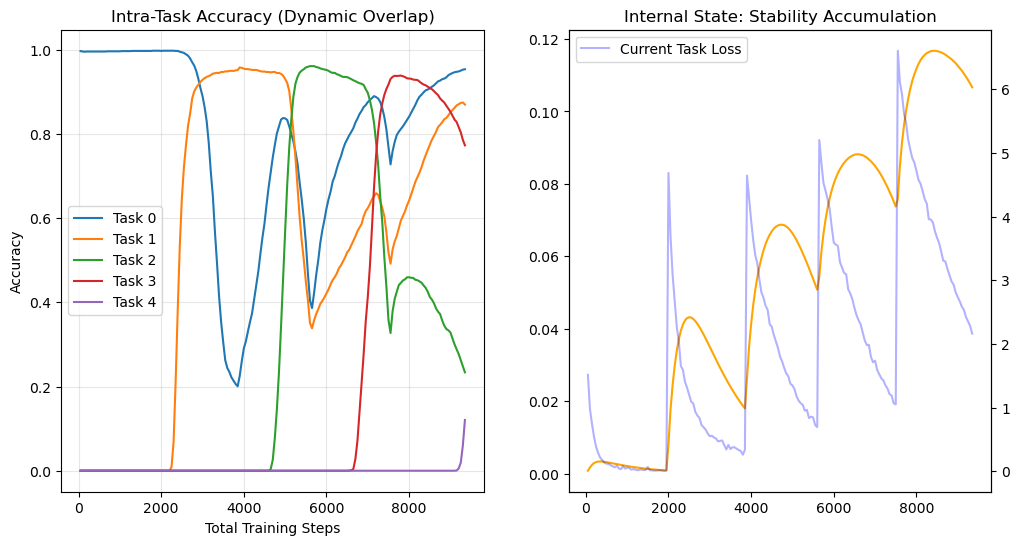

In [5]:
def plot_research_results(tracker):
    steps = tracker.history['steps']
    accs = np.array(tracker.history['accuracies'])

    plt.figure(figsize=(12, 6))

    # 1. Learning Curves (All Tasks)
    plt.subplot(1, 2, 1)
    for i in range(len(TASKS)):
        plt.plot(steps, accs[:, i], label=f'Task {i}')

    # Draw vertical lines for task boundaries
    steps_per_task = (len(train_x)//len(TASKS)//BATCH_SIZE) * EPOCHS_PER_TASK
    # (Note: This is an approximation; calculate exactly based on your split sizes)

    plt.title("Intra-Task Accuracy (Dynamic Overlap)")
    plt.xlabel("Total Training Steps")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)

    # 2. Stability Growth vs. Loss
    plt.subplot(1, 2, 2)
    plt.plot(steps, tracker.history['stability_means'], label='Mean Stability (S)', color='orange')
    plt.twinx()
    plt.plot(steps, tracker.history['losses'], label='Current Task Loss', color='blue', alpha=0.3)
    plt.title("Internal State: Stability Accumulation")
    plt.xlabel("Total Training Steps")
    plt.legend()
    plt.show()

plot_research_results(tracker)